In [14]:
%pip install osmnx folium geopandas matplotlib mapclassify contextily

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import osmnx as ox
import folium
import geopandas as gpd
from folium.plugins import Fullscreen, MiniMap

# Build cleaned interactive Folium map for CSU campus
place = "Colorado State University, Fort Collins, Colorado, USA"

# Fetch features once and reuse
tags = {
    "building": True,
    "highway": True,
    "leisure": True,
    "amenity": True,
    "sport": True,
    "landuse": True,
    "natural": True,
}
features = ox.features_from_place(place, tags)

# Compute center for map
campus = ox.geocode_to_gdf(place)
center = campus.geometry.iloc[0].centroid

# Create base map
m = folium.Map(location=[center.y, center.x], zoom_start=16, tiles="CartoDB positron")

# Helper to safely extract GeoDataFrames
def safe_gdf(df, col):
    try:
        return df[df.get(col).notna()] if col in df.columns else gpd.GeoDataFrame()
    except Exception:
        return gpd.GeoDataFrame()

buildings = safe_gdf(features, "building")
roads = safe_gdf(features, "highway")
sports = features[(features.get("leisure").notna() | features.get("sport").notna())] if ("leisure" in features.columns or "sport" in features.columns) else gpd.GeoDataFrame()
green = features[(features.get("landuse").isin(["grass", "recreation_ground"])) | features.get("natural").notna()] if ("landuse" in features.columns or "natural" in features.columns) else gpd.GeoDataFrame()

# Add GeoJSON layers with simple style functions
def add_layer(gdf, name, style):
    if gdf is None or gdf.empty:
        return
    folium.GeoJson(
        gdf.to_json(),
        name=name,
        style_function=lambda feat, s=style: s,
        tooltip=folium.GeoJsonTooltip(fields=[f for f in ["name"] if f in gdf.columns])
    ).add_to(m)

add_layer(buildings, "Buildings", {"color": "#2b5bff", "weight": 1, "fillColor": "#add8ff", "fillOpacity": 0.6})
add_layer(green, "Green Spaces", {"color": "green", "weight": 1, "fillColor": "lightgreen", "fillOpacity": 0.4})
add_layer(sports, "Sports", {"color": "orange", "weight": 1, "fillColor": "orange", "fillOpacity": 0.4})
add_layer(roads, "Roads", {"color": "#777777", "weight": 2})

# Controls & plugins
folium.LayerControl().add_to(m)
Fullscreen().add_to(m)
MiniMap().add_to(m)

# Save and display
m.save("csu_campus_interactive.html")
m

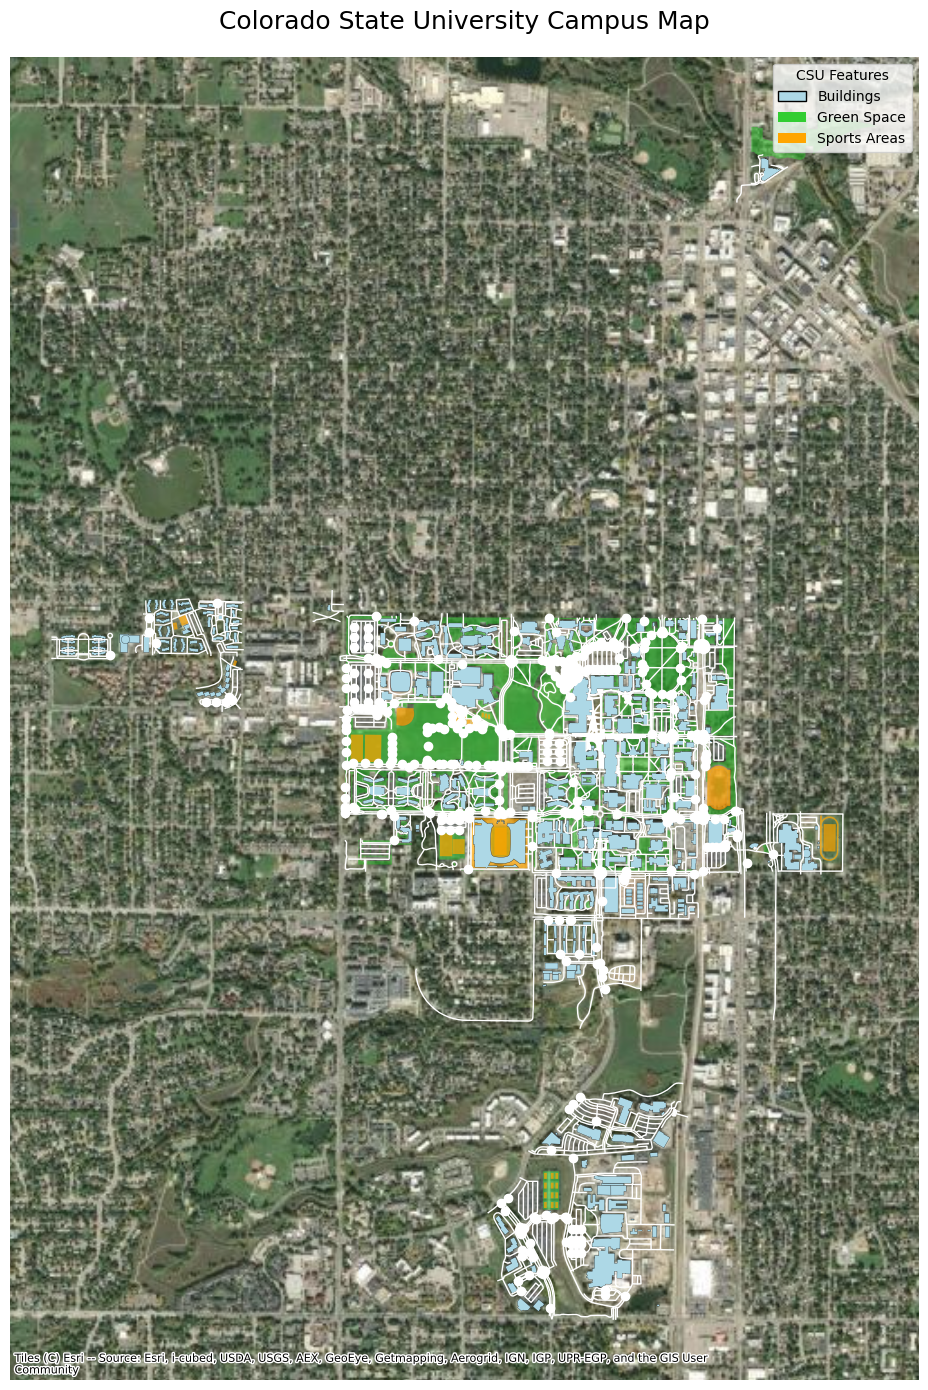

In [15]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Try to import contextily, install if missing
try:
    import contextily as ctx
except ModuleNotFoundError:
    import sys, subprocess
    print("contextily not found; installing via pip...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "contextily"]) 
    import contextily as ctx

# CSU Campus
place = "Colorado State University, Fort Collins, Colorado, USA"

# Download features
buildings = ox.features_from_place(place, {"building": True})
roads = ox.features_from_place(place, {"highway": True})
sports = ox.features_from_place(place, {"sport": True})
greenspace = ox.features_from_place(
    place,
    {"landuse": ["grass", "recreation_ground"]}
)

# Convert to Web Mercator
buildings = buildings.to_crs(epsg=3857)
roads = roads.to_crs(epsg=3857)
sports = sports.to_crs(epsg=3857)
greenspace = greenspace.to_crs(epsg=3857)

# Create figure
fig, ax = plt.subplots(figsize=(14, 14))

# Plot layers
greenspace.plot(
    ax=ax,
    color="limegreen",
    alpha=0.5,
    zorder=2
)

sports.plot(
    ax=ax,
    color="orange",
    alpha=0.7,
    zorder=3
)

buildings.plot(
    ax=ax,
    color="lightblue",
    edgecolor="black",
    linewidth=0.2,
    zorder=4
)

roads.plot(
    ax=ax,
    color="white",
    linewidth=1,
    zorder=5
)

# Satellite basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    alpha=0.9
)

# Legend
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='black', label='Buildings'),
    Patch(facecolor='limegreen', label='Green Space'),
    Patch(facecolor='orange', label='Sports Areas'),
]

ax.legend(
    handles=legend_elements,
    loc='upper right',
    title='CSU Features'
)

plt.title(
    "Colorado State University Campus Map",
    fontsize=18,
    pad=20
)

plt.axis("off")
plt.tight_layout()
plt.show()